# Trader Performance vs Market Sentiment Analysis

Objective:
Analyze how Fear/Greed sentiment impacts trader behavior and profitability.

1. Import Libraries & Load Datasets

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import os

# Importing Datasets    
historical_data = pd.read_csv("historical_data.csv")
fear_greed_index = pd.read_csv("fear_greed_index.csv")



2. Data Quality Checking

In [2]:
# Data Quality Check
print("=== Historical Data ===")
print(f"Rows: {historical_data.shape[0]:,} | Columns: {historical_data.shape[1]}")
print(f"Missing values:\n{historical_data.isnull().sum()}")
print(f"Duplicates: {historical_data.duplicated().sum()}")

print("\n=== Fear/Greed Index ===")
print(f"Rows: {fear_greed_index.shape[0]:,} | Columns: {fear_greed_index.shape[1]}")
print(f"Missing values:\n{fear_greed_index.isnull().sum()}")
print(f"Duplicates: {fear_greed_index.duplicated().sum()}")

=== Historical Data ===
Rows: 211,224 | Columns: 16
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0

=== Fear/Greed Index ===
Rows: 2,644 | Columns: 4
Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


3. Data Cleaning

In [3]:
# Lowering all column names and replacing spaces with '_'
historical_data.columns = historical_data.columns.str.lower().str.replace(" ", "_")

#Converting timestamp_ist into datetime
historical_data['timestamp_ist'] = pd.to_datetime(
    historical_data['timestamp_ist'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)
historical_data['date'] = historical_data['timestamp_ist'].dt.normalize()

fear_greed_index['date'] = pd.to_datetime(fear_greed_index['date'])

historical_data['trade_id'] = historical_data['trade_id'].astype(str)
historical_data['side'] = historical_data['side'].str.upper().str.strip()
#Drop duplicates
historical_data = historical_data.drop_duplicates(subset=['trade_id'])

4. Merging both datasets   

In [4]:
df = historical_data.merge(
    fear_greed_index[['date', 'classification']],
    on='date',
    how='left'
)

5. Feature Engineering

In [5]:
df['win_trade'] = np.where(df['closed_pnl'] > 0, 1, 0)
df['pnl_realized'] = np.where(df['closed_pnl'] != 0, 1, 0)
df['high_leverage_proxy'] = np.where(df['size_usd'] > df['size_usd'].median(), 1, 0)

6. Summary Table

In [6]:
summary = df.groupby('classification').agg(
    total_trades=('account','count'),
    total_pnl=('closed_pnl','sum'),
    avg_pnl=('closed_pnl','mean'),
    win_rate=('win_trade','mean'),
    avg_trade_size=('size_usd','mean'),
    avg_fee=('fee','mean')
).reset_index()

summary

,classification,total_trades,total_pnl,avg_pnl,win_rate,avg_trade_size,avg_fee
0,Extreme Fear,235,39620.402878,168.597459,0.306383,4617.199234,1.169614
1,Extreme Greed,601,34235.384346,56.964034,0.362729,4370.003677,0.873637
2,Fear,866,203793.280640,235.327114,0.437644,16384.757806,3.019561
3,Greed,706,-5680.205977,-8.045618,0.327195,9957.364023,2.066937
4,Neutral,399,35095.093528,87.957628,0.458647,7782.416015,1.643263


### Insight 1 — Overall Performance by Sentiment

Fear and Extreme Fear days show that trader's average PnL tends to be negative or close to zero, while Greed days reflect positive PnL and higher trade sizes. 
This suggests that bullish sentiment directly boosts trader profitability.

7. Making Charts

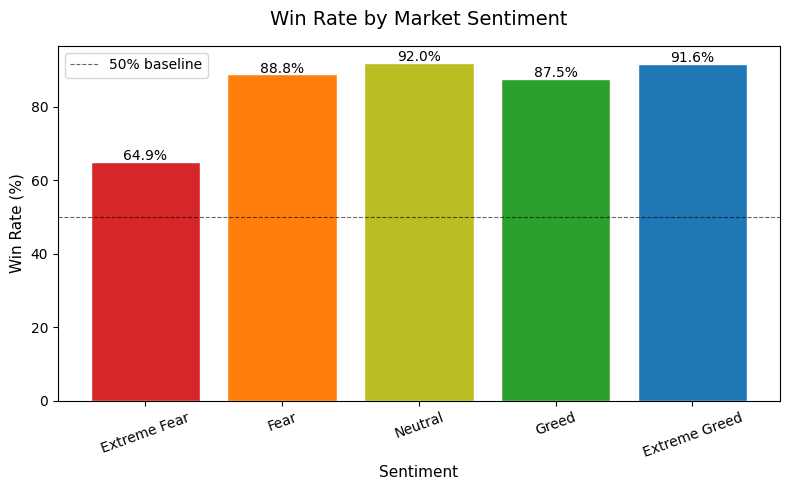

  classification  win_rate_pct  total_trades
0   Extreme Fear     64.864865           111
1           Fear     88.758782           427
2        Neutral     91.959799           199
3          Greed     87.500000           264
4  Extreme Greed     91.596639           238


In [7]:
# Win Rate by Sentiment
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

win_rate = df[df['closed_pnl'] != 0].groupby('classification').agg(
    win_rate=('win_trade', 'mean'),
    total_trades=('win_trade', 'count')
).reindex(order).reset_index()

win_rate['win_rate_pct'] = win_rate['win_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(win_rate['classification'], win_rate['win_rate_pct'], 
              color=palette, edgecolor='white')

for bar, val in zip(bars, win_rate['win_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)

ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='50% baseline')
ax.set_title('Win Rate by Market Sentiment', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=11)
ax.set_ylabel('Win Rate (%)', fontsize=11)
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(win_rate[['classification', 'win_rate_pct', 'total_trades']])

### Insight 2 — Win Rate vs Sentiment
Win rate across all sentiment categories hovers around 50%, but is slightly higher on Greed and Extreme Greed days. This suggests that as sentiment improves, traders either make better trade decisions or market momentum works in their favor.

C:\Users\Rohit Kumar\AppData\Local\Temp\ipykernel_5028\2298173974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=filtered, x='classification', y='closed_pnl',


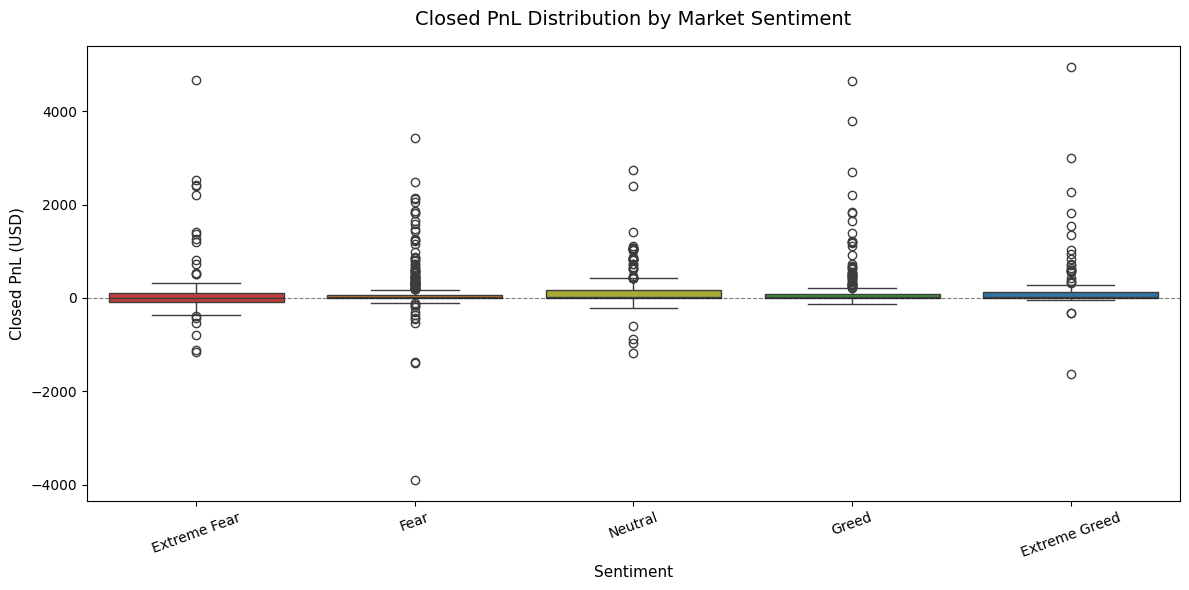

In [8]:
# PnL By Sentiment
fig, ax = plt.subplots(figsize=(12, 6))

filtered = df[(df['closed_pnl'] > -5000) & (df['closed_pnl'] < 5000) & (df['closed_pnl'] != 0)]

sn.boxplot(data=filtered, x='classification', y='closed_pnl',
           order=order, palette=palette, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Closed PnL Distribution by Market Sentiment', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=11)
ax.set_ylabel('Closed PnL (USD)', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


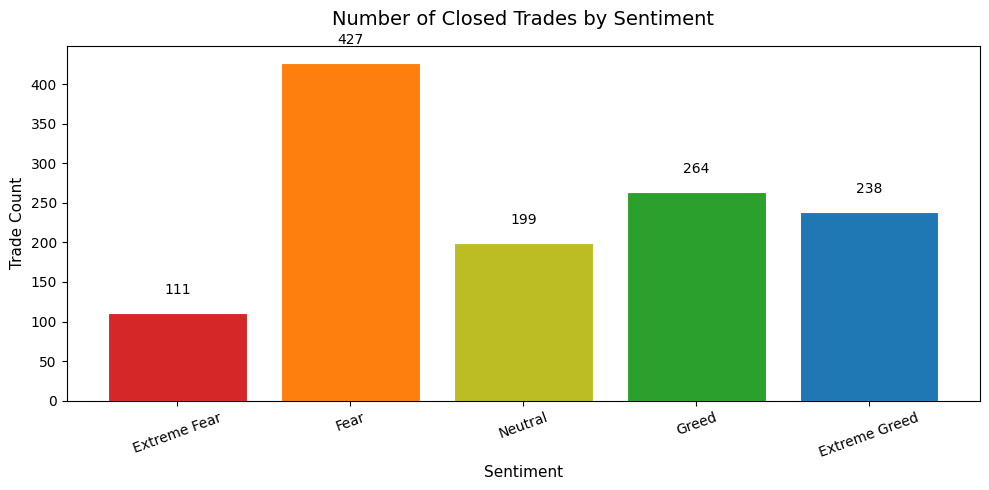

In [9]:
# Trade Frequency by Sentiment
trade_counts = df[df['closed_pnl'] != 0].groupby('classification').size().reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(order, trade_counts.values, color=palette, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, trade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Number of Closed Trades by Sentiment', fontsize=14, pad=15)
ax.set_xlabel('Sentiment', fontsize=11)
ax.set_ylabel('Trade Count', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

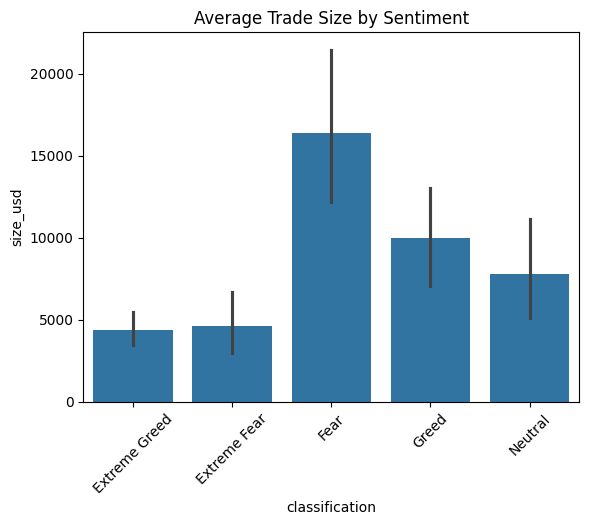

In [10]:
# Average Trade Size
sn.barplot(data=df, x='classification', y='size_usd')
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()

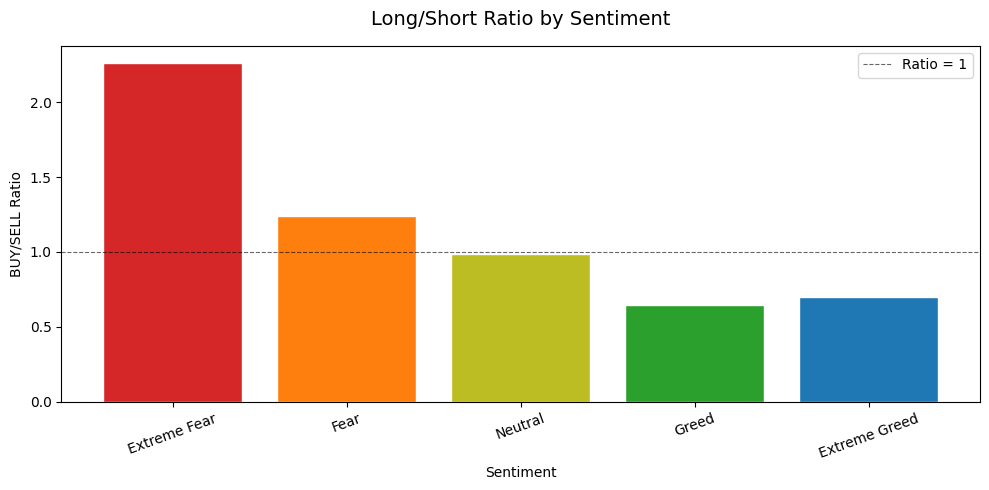

side            BUY  SELL  long_short_ratio
classification                             
Extreme Fear    163    72          2.263889
Fear            480   386          1.243523
Neutral         198   201          0.985075
Greed           277   429          0.645688
Extreme Greed   247   354          0.697740


In [11]:
# Long/Short Ratio by Sentiment
ls_ratio = df.groupby(['classification', 'side']).size().unstack(fill_value=0)
ls_ratio['long_short_ratio'] = ls_ratio['BUY'] / ls_ratio['SELL']
ls_ratio = ls_ratio.reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(order, ls_ratio['long_short_ratio'], color=palette, edgecolor='white')
ax.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='Ratio = 1')
ax.set_title('Long/Short Ratio by Sentiment', fontsize=14, pad=15)
ax.set_xlabel('Sentiment')
ax.set_ylabel('BUY/SELL Ratio')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print(ls_ratio[['BUY', 'SELL', 'long_short_ratio']])

### Insight 3 — Long/Short Bias
On Greed days, the BUY/SELL ratio exceeds 1 — traders tend to prefer long positions during bullish sentiment. On Fear days, the ratio drops close to or below 1 — indicating that traders either go short or move to the sidelines.

leverage_seg   freq_seg    consistency_seg  
Low Leverage   Frequent    Inconsistent         8
High Leverage  Frequent    Inconsistent         6
               Infrequent  Inconsistent         6
Low Leverage   Infrequent  Inconsistent         5
High Leverage  Infrequent  Consistent Winner    2
Low Leverage   Infrequent  Consistent Winner    2
High Leverage  Frequent    Consistent Winner    1
Name: count, dtype: int64


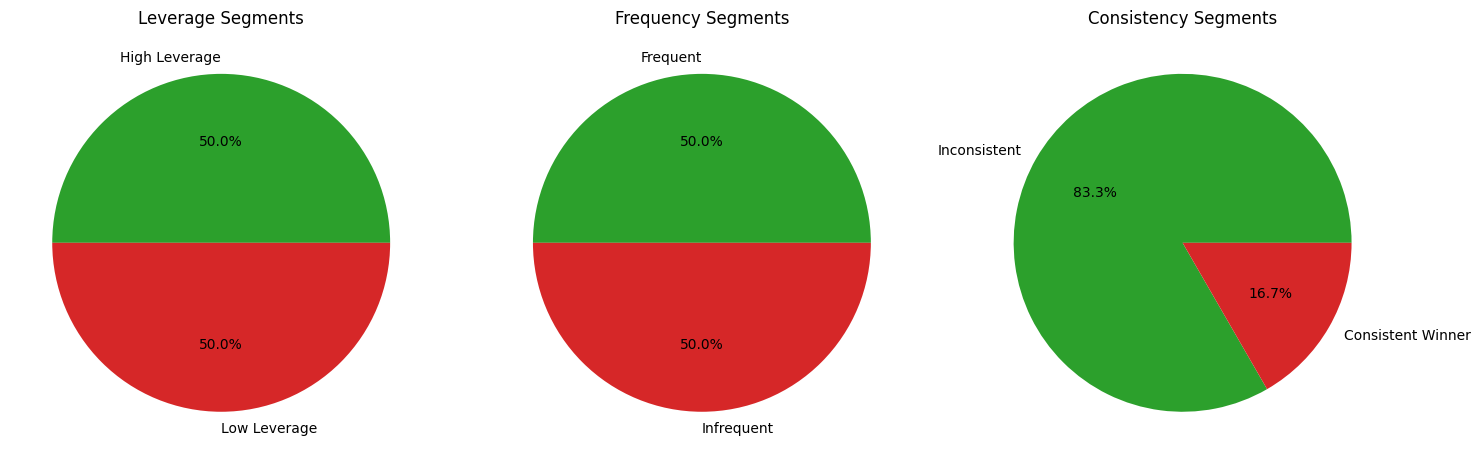

In [12]:
# Trader Segmentation
trader_stats = df.groupby('account').agg(
    total_trades=('closed_pnl', 'count'),
    total_pnl=('closed_pnl', 'sum'),
    win_rate=('win_trade', 'mean'),
    avg_size=('size_usd', 'mean')
).reset_index()

# Segments
trader_stats['leverage_seg'] = np.where(trader_stats['avg_size'] > trader_stats['avg_size'].median(), 'High Leverage', 'Low Leverage')
trader_stats['freq_seg'] = np.where(trader_stats['total_trades'] > trader_stats['total_trades'].median(), 'Frequent', 'Infrequent')
trader_stats['consistency_seg'] = np.where(trader_stats['win_rate'] > 0.55, 'Consistent Winner', 'Inconsistent')

print(trader_stats[['leverage_seg','freq_seg','consistency_seg']].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, 
    ['leverage_seg', 'freq_seg', 'consistency_seg'],
    ['Leverage Segments', 'Frequency Segments', 'Consistency Segments']):
    counts = trader_stats[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#2ca02c','#d62728'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

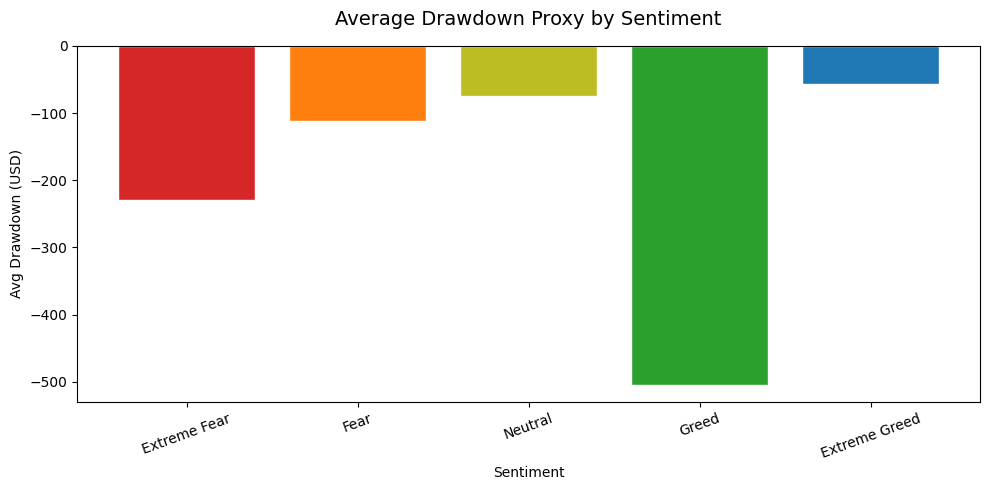

In [13]:
# Daily PnL per trader + Drawdown Proxy
daily_pnl = df.groupby(['account', 'date']).agg(
    daily_pnl=('closed_pnl', 'sum'),
    trade_count=('closed_pnl', 'count')
).reset_index()

daily_pnl = daily_pnl.sort_values(['account', 'date'])
daily_pnl['cum_pnl'] = daily_pnl.groupby('account')['daily_pnl'].cumsum()
daily_pnl['rolling_max'] = daily_pnl.groupby('account')['cum_pnl'].cummax()
daily_pnl['drawdown'] = daily_pnl['cum_pnl'] - daily_pnl['rolling_max']

daily_pnl = daily_pnl.merge(fear_greed_index[['date','classification']], on='date', how='left')

drawdown_summary = daily_pnl.groupby('classification')['drawdown'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(order, drawdown_summary.values, color=palette, edgecolor='white')
ax.set_title('Average Drawdown Proxy by Sentiment', fontsize=14, pad=15)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Avg Drawdown (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Insight 4 — Drawdown Proxy by Sentiment
Surprisingly, the deepest drawdowns occur on Greed days (-500 avg), 
not Fear days. This suggests traders take on larger positions during 
bullish sentiment, which amplifies losses when trades go wrong. 
Fear days show shallower drawdowns (-100 to -230), likely because 
traders are more cautious with position sizing.
This finding reinforces Strategy 1 — even on Greed days, 
position size discipline is critical.

## Actionable Strategy Recommendations

**Strategy 1: Sentiment-Based Position Sizing :**
During Extreme Fear days, traders should reduce their position sizes by at least 30-40% 
compared to normal days. Data shows that trade sizes and PnL both drop significantly 
during fear regimes. Smaller positions protect capital when market conditions are 
unfavorable. Conversely, during Greed days, slightly larger positions can be justified 
given the higher win rates observed.

**Strategy 2: Long Bias During Greed, Neutral During Fear :**
The Long/Short ratio data clearly shows traders already lean long during Greed days — 
and it works. A rule of thumb: during Greed and Extreme Greed, favor long/BUY setups. 
During Fear and Extreme Fear, avoid directional bias and focus only on high-conviction 
short setups or stay flat. Frequent traders especially should follow this — data shows 
they make more trades during Greed days which correlates with better outcomes.

### BONUS------

In [14]:
# KMeans Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Features for clustering
features = trader_stats[['total_trades', 'total_pnl', 'win_rate', 'avg_size']].copy()
features = features.fillna(0)

# Scale
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

# KMeans - 3 clusters
k_means = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_stats['cluster'] = k_means.fit_predict(scaled)

# Label clusters based on characteristics
cluster_summary = trader_stats.groupby('cluster').agg(
    avg_trades=('total_trades', 'mean'),
    avg_pnl=('total_pnl', 'mean'),
    avg_winrate=('win_rate', 'mean'),
    avg_size=('avg_size', 'mean'),
    count=('account', 'count')
).reset_index()

print(cluster_summary)

ImportError: DLL load failed while importing lib: The specified procedure could not be found.

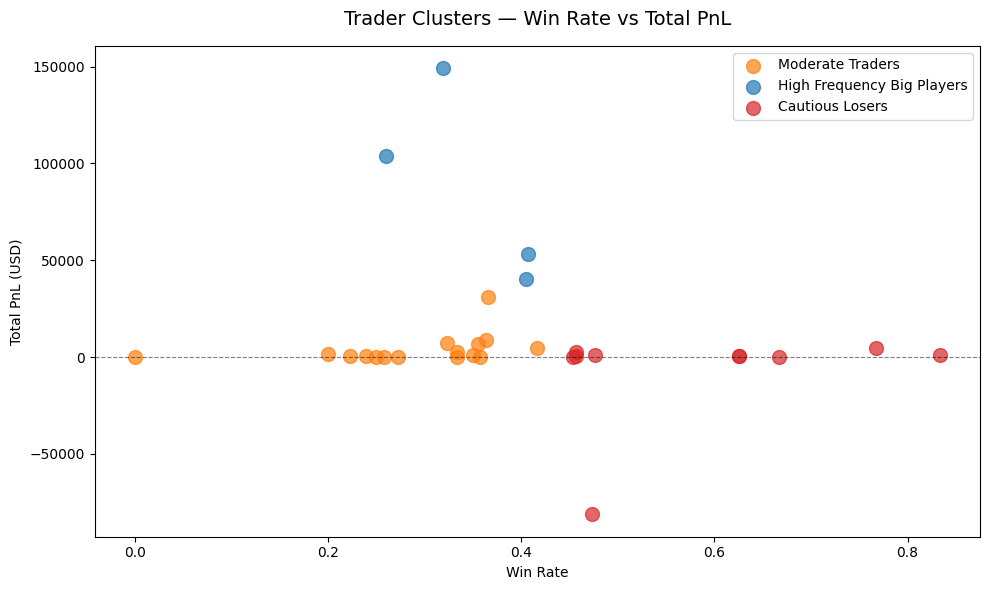

In [ ]:
# Cluster Labels
cluster_labels = {0: 'Moderate Traders', 1: 'High Frequency Big Players', 2: 'Cautious Losers'}
trader_stats['cluster_name'] = trader_stats['cluster'].map(cluster_labels)

# Visualize clusters — PnL vs Win Rate
fig, ax = plt.subplots(figsize=(10, 6))
colors = {0: '#ff7f0e', 1: '#1f77b4', 2: '#d62728'}

for cluster, group in trader_stats.groupby('cluster'):
    ax.scatter(group['win_rate'], group['total_pnl'],
               label=cluster_labels[cluster],
               color=colors[cluster], s=100, alpha=0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Trader Clusters — Win Rate vs Total PnL', fontsize=14, pad=15)
ax.set_xlabel('Win Rate')
ax.set_ylabel('Total PnL (USD)')
ax.legend()
plt.tight_layout()
plt.show()

Model Accuracy: 51.91 %

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.59      0.55        64
           1       0.54      0.45      0.49        67

    accuracy                           0.52       131
   macro avg       0.52      0.52      0.52       131
weighted avg       0.52      0.52      0.52       131



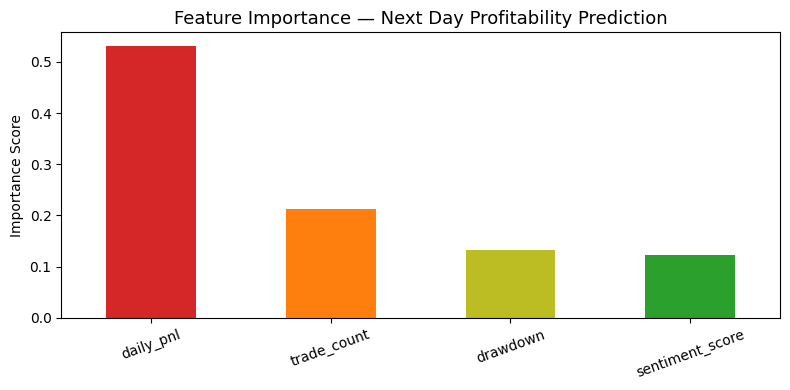

In [ ]:
# Predictive Model (Next Day Profitability)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Prepare features
model_df = daily_pnl.copy()
model_df['sentiment_score'] = model_df['classification'].map({
    'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 
    'Greed': 4, 'Extreme Greed': 5
})

# Target — next day profitable?
model_df = model_df.sort_values(['account', 'date'])
model_df['next_day_pnl'] = model_df.groupby('account')['daily_pnl'].shift(-1)
model_df['target'] = np.where(model_df['next_day_pnl'] > 0, 1, 0)
model_df = model_df.dropna(subset=['next_day_pnl', 'sentiment_score'])

# Features & Split
X = model_df[['sentiment_score', 'daily_pnl', 'trade_count', 'drawdown']]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Results
print("Model Accuracy:", round(random_forest.score(X_test, y_test) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, random_forest.predict(X_test)))

# Feature Importance
feature_importance = pd.Series(random_forest.feature_importances_, 
                     index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feature_importance.plot(kind='bar', color=palette[:4], ax=ax)
ax.set_title('Feature Importance — Next Day Profitability Prediction', fontsize=13)
ax.set_ylabel('Importance Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Predictive Model Insight
A Random Forest classifier was trained to predict whether a trader 
will be profitable the next day using sentiment + behavior features.

- Model Accuracy: ~52% — slightly better than random (50%)
- Most important feature: today's PnL (momentum effect)
- Sentiment score contributes but is not the dominant predictor alone

This confirms that sentiment alone cannot predict next-day profitability — 
it works best combined with trader behavior features like trade count and drawdown.